In [1]:
# Notebook: Algorithm Performance Over Time
#
# Tracks liked rate and superlike rate for each recommendation algorithm
# (feed slot / priority) week by week, so we can spot trends, regressions,
# and which algos are improving or declining over time.

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

# Connect to the museiq database and expose `connection`, `engine`, and `DB`
%run db.py

In [2]:
def get_algo_performance(start_date='2025-01-01'):
    """
    Load weekly liked and superlike rates per algorithm from the eventlog.

    Returns a DataFrame with columns:
      week, message (algo name), priority, liked, superliked, cnt
    """
    sql = '''
        SELECT
            DATE(DATE_SUB(e.timestamp, INTERVAL WEEKDAY(e.timestamp) DAY)) AS week,
            MAX(message)  AS message,
            priority,
            AVG(action = 'song_add' OR action = 'song_superlike') AS liked,
            AVG(action = 'song_superlike')                         AS superliked,
            COUNT(*)                                               AS cnt
        FROM eventlog e
        INNER JOIN users u  ON e.user_id   = u.id
        INNER JOIN artists a ON e.artist_id = a.id
        WHERE action IN ('song_add', 'song_next', 'song_superlike')
          AND priority IS NOT NULL
          AND e.timestamp >= '%s'
        GROUP BY week, priority
        ORDER BY week ASC, priority ASC
    ''' % start_date
    rows = DB.fetch(sql)
    df = pd.DataFrame(rows)
    df['week']       = pd.to_datetime(df['week'])
    df['liked']      = df['liked'].astype(float)
    df['superliked'] = df['superliked'].astype(float)
    df['cnt']        = df['cnt'].astype(int)
    print(f"Loaded {len(df):,} (week, algo) rows")
    return df

df = get_algo_performance(start_date='2025-01-01')

Loaded 1,133 (week, algo) rows


In [3]:
# Preview: latest week snapshot sorted by superlike rate
latest_week = df['week'].max()
print(f"Latest week: {latest_week.date()}")
df[df['week'] == latest_week][['message', 'liked', 'superliked', 'cnt']]\
    .sort_values('superliked', ascending=False)

Latest week: 2026-03-16


,message,liked,superliked,cnt
1130,Male,0.7115,0.4038,52
1115,spotify_algo,0.6500,0.4000,20
1123,%trance%,0.6628,0.2791,86
1125,spotify_algo_genre,0.5455,0.2727,11
1118,superlike_algo,0.6755,0.2663,1476
1119,explore superlikes,0.7419,0.2613,1542
1132,trades,0.5000,0.2500,12
1116,svd_recommendation,0.7198,0.2391,2702
1117,piki explore,0.6026,0.1599,1520
1131,random users superlikes,0.4386,0.1186,472


In [4]:
# Only plot algos that have meaningful volume (>=500 events in the latest week)
# to avoid noise from low-traffic slots.
MIN_CNT = 500

latest = df[df['week'] == latest_week]
active_algos = latest[latest['cnt'] >= MIN_CNT]['message'].tolist()
print(f"{len(active_algos)} active algos (>={MIN_CNT} events last week):")
print(active_algos)

6 active algos (>=500 events last week):
['promoted songs', 'svd_recommendation', 'piki explore', 'superlike_algo', 'explore superlikes', 'investments']


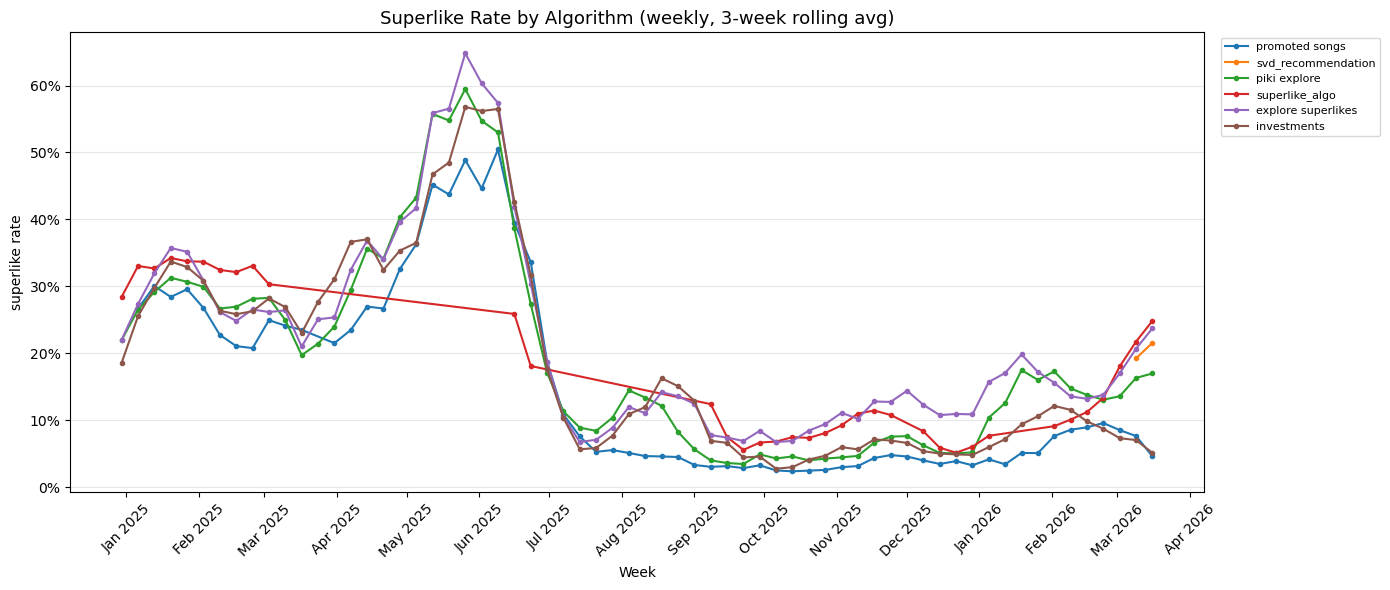

In [5]:
def plot_metric_over_time(df, metric, algos, title, min_cnt=500, rolling_weeks=3):
    """
    Plot a metric (liked or superliked) over time for a list of algorithms.
    Low-volume weeks (< min_cnt) are suppressed.  A rolling average smooths noise.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    for algo in algos:
        sub = df[df['message'] == algo].copy()
        sub = sub[sub['cnt'] >= min_cnt].sort_values('week')
        if len(sub) < 2:
            continue
        # rolling average to smooth week-to-week noise
        smoothed = sub.set_index('week')[metric].rolling(rolling_weeks, min_periods=1).mean()
        ax.plot(smoothed.index, smoothed.values, marker='o', markersize=3, label=algo)

    ax.set_title(title, fontsize=13)
    ax.set_ylabel(metric.replace('liked', 'like rate'))
    ax.set_xlabel('Week')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_over_time(df, 'superliked', active_algos,
                      'Superlike Rate by Algorithm (weekly, 3-week rolling avg)')

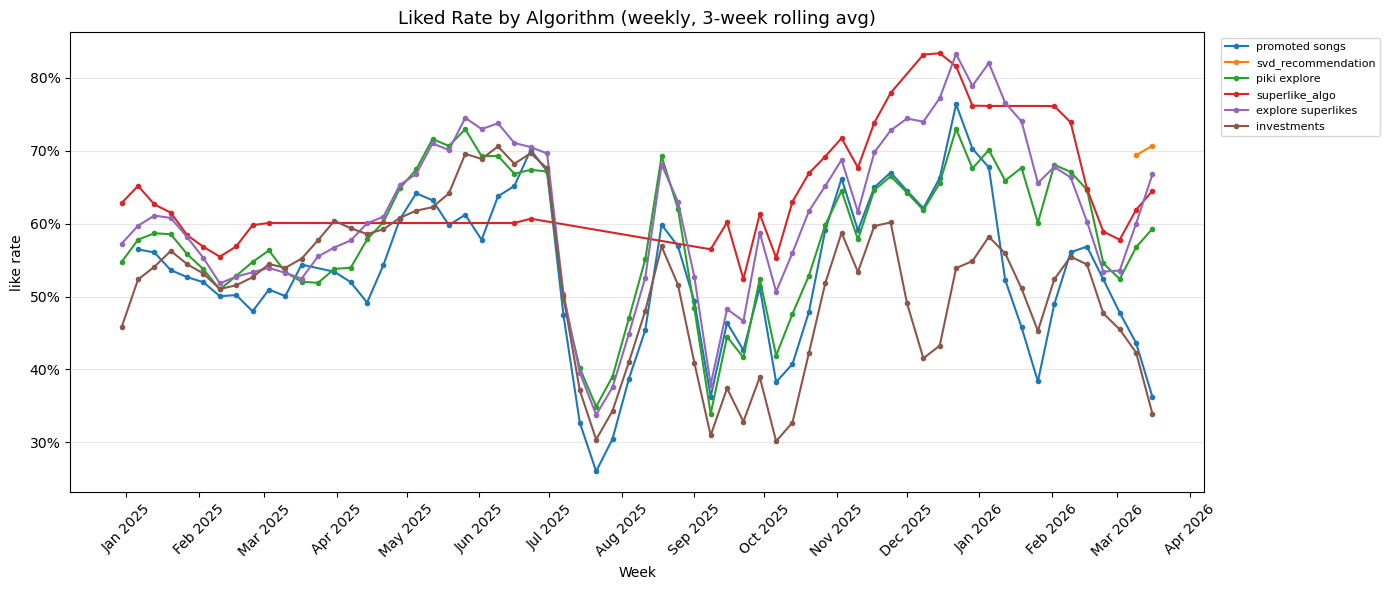

In [6]:
plot_metric_over_time(df, 'liked', active_algos,
                      'Liked Rate by Algorithm (weekly, 3-week rolling avg)')

In [7]:
# Summary table: each algo's avg liked/superliked over the last 4 weeks
four_weeks_ago = latest_week - pd.Timedelta(weeks=4)
recent = df[df['week'] > four_weeks_ago]

summary = (
    recent.groupby('message')
    .apply(lambda g: pd.Series({
        'superliked': (g['superliked'] * g['cnt']).sum() / g['cnt'].sum(),
        'liked':      (g['liked']      * g['cnt']).sum() / g['cnt'].sum(),
        'cnt':        g['cnt'].sum()
    }))
    .reset_index()
    .sort_values('superliked', ascending=False)
)
summary

,message,superliked,liked,cnt
21,svd_recommendation,0.224224,0.711454,3965.0
20,superlike_algo,0.218957,0.620847,10458.0
19,spotify_algo_genre,0.216643,0.633340,60.0
11,explore superlikes,0.202381,0.595593,11716.0
18,spotify_algo,0.195651,0.739110,92.0
1,%trap%,0.176594,0.602275,538.0
22,trades,0.175583,0.501270,393.0
13,piki explore,0.156094,0.557872,16676.0
14,piki genre,0.124486,0.596123,2362.0
3,Male,0.123083,0.458478,325.0


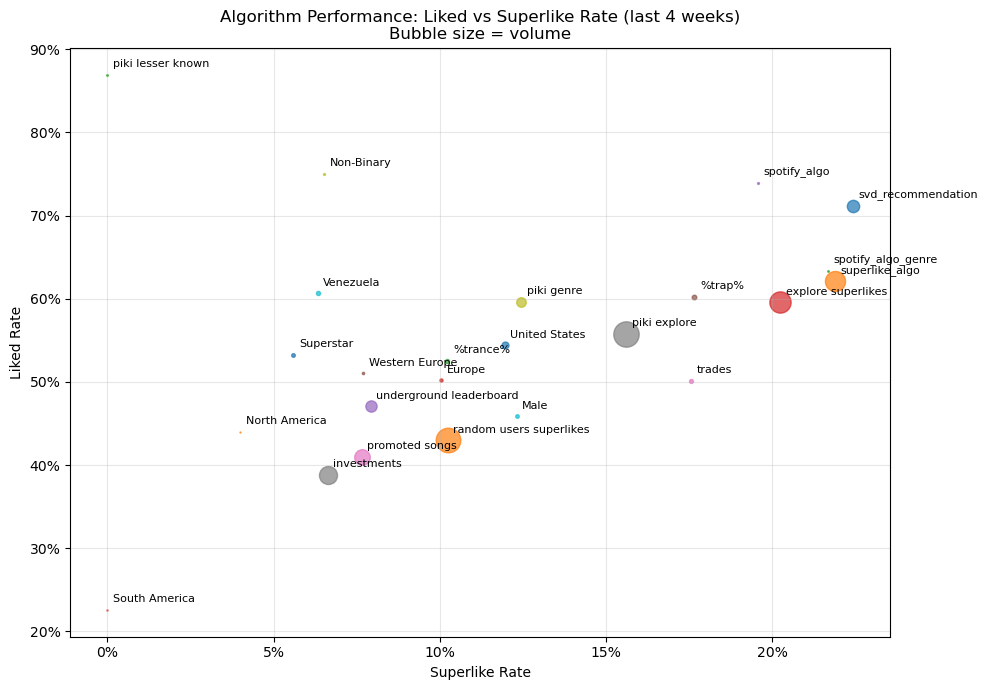

In [8]:
# Scatter plot: each algo as a point — x=superlike rate, y=liked rate
# Size encodes volume; label each point with the algo name.
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in summary.iterrows():
    ax.scatter(row['superliked'], row['liked'], s=row['cnt'] / 50, alpha=0.7)
    ax.annotate(row['message'], (row['superliked'], row['liked']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Superlike Rate')
ax.set_ylabel('Liked Rate')
ax.set_title('Algorithm Performance: Liked vs Superlike Rate (last 4 weeks)\nBubble size = volume')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()